# Índice de Potencial Solar-Climático (IPS) — Cortés

**Proyecto de Sostenibilidad (Parcial 1) — Línea base ambiental / cierre climático**
Autor: Diego Cárcamo

Este notebook construye un índice compuesto que responde la pregunta central del bloque
solar: *de los 12 municipios de Cortés, ¿cuáles combinan alta irradiación/generación solar,
bajo o moderado riesgo climático e infraestructura aceptable?*

A diferencia de la versión anterior (que calculaba un índice sobre los 298 municipios del
país), aquí el análisis se hace **directamente sobre los 12 municipios de Cortés**, que es el
territorio elegido para el proyecto — evita mezclar la escala de comparación nacional con la
decisión de preselección local, y permite usar la clasificación en terciles (bajo/medio/alto)
tal como se definió para este entregable.

**Insumo:** `dataset_indicadores_municipales_enriquecido.csv`, producido por
`gda.ipynb` (incluye GHI y PVOUT ya fusionados con los indicadores de riesgo climático,
infraestructura y desarrollo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data/index/processed/dataset_indicadores_municipales_enriquecido.csv"
DEPARTAMENTO_FOCO = "HN05"  # Cortes

df_nacional = pd.read_csv(DATA_PATH)
df = df_nacional[df_nacional["codigo_departamental"] == DEPARTAMENTO_FOCO].reset_index(drop=True)
assert len(df) == 12, f"Se esperaban 12 municipios de Cortes, se obtuvieron {len(df)}"
df.head(12)


,departamento,municipio,solar_power_mean,solar_power_min,solar_power_max,codigo_departamental,codigo_municipal,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura,ice,iae,pvout_mean,pvout_min,pvout_max,pvout_count
0,Cortes,Puerto Cortes,1935.149874,1793.011963,2006.683960,HN05,HN0506,9.3,9.4,0.0,3.6,0.0,7.7,3.3,5.2,4.4,0.9700,0.9731,1568.190027,1478.896973,1622.806030,470
1,Cortes,Omoa,1773.281026,1502.637939,1946.781982,HN05,HN0503,8.4,9.3,0.0,5.6,0.0,7.8,6.7,6.4,6.2,0.9106,0.9216,1434.468620,1256.824951,1566.921997,482
2,Cortes,Choloma,1880.486177,1506.291016,1964.680054,HN05,HN0502,9.9,9.8,0.0,5.4,0.0,8.3,4.8,5.2,4.6,0.9727,0.9741,1523.873900,1280.201050,1584.453979,568
3,Cortes,San Pedro Sula,1765.359245,1331.701050,1989.516968,HN05,HN0501,10.0,10.0,0.0,6.6,0.0,8.4,0.7,4.5,3.7,0.9794,0.9810,1437.203739,1125.699951,1597.238037,1043
4,Cortes,La Lima,1969.962451,1944.956055,1990.612061,HN05,HN0512,8.8,9.7,0.0,4.6,0.0,7.8,3.3,4.9,5.3,0.9624,0.9626,1582.066866,1565.461060,1597.968994,136
5,Cortes,San Manuel,1965.433403,1908.796021,1985.499023,HN05,HN0509,8.6,9.3,0.0,2.7,0.0,8.5,3.3,5.5,5.5,0.9607,0.9607,1576.124632,1551.217041,1592.125000,170
6,Cortes,San Antonio De Cortes,1946.788571,1695.490967,2025.676025,HN05,HN0507,7.7,8.8,0.0,3.7,0.0,6.8,6.7,7.2,7.7,0.8355,0.9187,1568.550651,1488.759033,1616.962036,269
7,Cortes,Santa Cruz De Yojoa,1960.350046,1632.667969,2032.250977,HN05,HN0510,8.8,9.5,0.0,4.6,0.0,7.6,5.0,5.9,5.3,0.8871,0.8969,1578.516930,1420.457031,1626.093018,886
8,Cortes,Villanueva,1932.817660,1788.264038,1980.020020,HN05,HN0511,7.4,9.3,0.0,4.4,0.0,8.2,3.3,5.3,5.5,0.9584,0.9588,1559.014881,1500.447021,1597.238037,420
9,Cortes,Pimienta,1973.704833,1924.136963,1994.630005,HN05,HN0504,7.6,9.5,0.0,0.0,0.0,7.6,5.4,5.9,6.0,0.9506,0.9506,1581.178079,1558.886963,1593.586060,68


## Bloque 1 — Análisis descriptivo (missing, varianza, distribución)

Antes de normalizar nada: ¿qué columnas tienen datos faltantes?, ¿cuáles casi no varían
*dentro de Cortés* (aunque sí varíen a nivel nacional)?, ¿hay outliers?

**Nota metodológica:** con n=12 (los 12 municipios), el coeficiente de variación, el método
IQR de outliers y las correlaciones son descriptivos, no inferenciales — se usan para
justificar decisiones de diseño del índice, no como prueba estadística formal. Se documenta
explícitamente como supuesto de este análisis, ya que trabajar con una muestra pequeña es una
limitación real que debe declararse (no se puede "arreglar" con más filas: son todos los
municipios que tiene el departamento).

In [2]:
def missing_report(data: pd.DataFrame) -> pd.DataFrame:
    """Conteo y porcentaje de datos faltantes por columna, orden descendente."""
    report = pd.DataFrame({
        "missing_count": data.isnull().sum(),
        "missing_pct": (data.isnull().mean() * 100).round(2),
    })
    return report.sort_values("missing_pct", ascending=False)


def variance_report(data: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """Coeficiente de variación (CV) por columna numérica. Un CV ~0 (o indefinido, si la
    media es 0) significa que la variable no discrimina entre los municipios de la muestra
    y es candidata a excluirse del índice."""
    stats = data[numeric_cols].agg(["mean", "std"]).T
    stats["cv"] = (stats["std"] / stats["mean"].replace(0, np.nan)).abs()
    return stats.sort_values("cv")


def outlier_report(data: pd.DataFrame, numeric_cols: list) -> pd.Series:
    """Marca columnas con outliers usando el método IQR (1.5x rango intercuartílico)."""
    outlier_counts = {}
    for col in numeric_cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_counts[col] = int(((data[col] < lower) | (data[col] > upper)).sum())
    return pd.Series(outlier_counts, name="outlier_count").sort_values(ascending=False)


id_cols = ["Unnamed: 0", "codigo_departamental", "codigo_municipal"]
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_cols]

print("=== Datos faltantes ===")
display(missing_report(df))

print("=== Coeficiente de variacion (CV) ===")
display(variance_report(df, numeric_cols))

print("=== Outliers (metodo IQR) ===")
display(outlier_report(df, numeric_cols))


=== Datos faltantes ===


,missing_count,missing_pct
departamento,0,0.0
municipio,0,0.0
solar_power_mean,0,0.0
solar_power_min,0,0.0
solar_power_max,0,0.0
codigo_departamental,0,0.0
codigo_municipal,0,0.0
poblacion_expuesta_a_terremotos,0,0.0
poblacion_expuesta_a_inundaciones,0,0.0
poblacion_expuesta_a_ciclones_y_marejadas,0,0.0


=== Coeficiente de variacion (CV) ===


,mean,std,cv
pvout_max,1602.108266,17.448522,0.010891
solar_power_max,1997.034760,26.488058,0.013264
iae,0.947550,0.026430,0.027893
pvout_mean,1548.484702,55.300558,0.035713
solar_power_mean,1921.664318,76.313312,0.039712
ice,0.938200,0.042426,0.045221
poblacion_expuesta_a_incendios_forestales,7.758333,0.528219,0.068084
pvout_min,1443.254842,144.792164,0.100323
poblacion_expuesta_a_terremotos,8.508333,0.888777,0.104460
solar_power_min,1733.628672,201.250020,0.116086


=== Outliers (metodo IQR) ===


solar_power_mean                             2
pvout_mean                                   2
ice                                          1
poblacion_expuesta_a_inundaciones            1
infraestructura                              1
poblacion_expuesta_a_deslizamientos          1
pvout_min                                    1
solar_power_min                              0
poblacion_expuesta_a_terremotos              0
solar_power_max                              0
capacidad_de_respuesta                       0
poblacion_expuesta_a_incendios_forestales    0
poblacion_afectada_por_sequia                0
poblacion_expuesta_a_ciclones_y_marejadas    0
iae                                          0
desarrollo_y_pobreza                         0
pvout_max                                    0
pvout_count                                  0
Name: outlier_count, dtype: int64

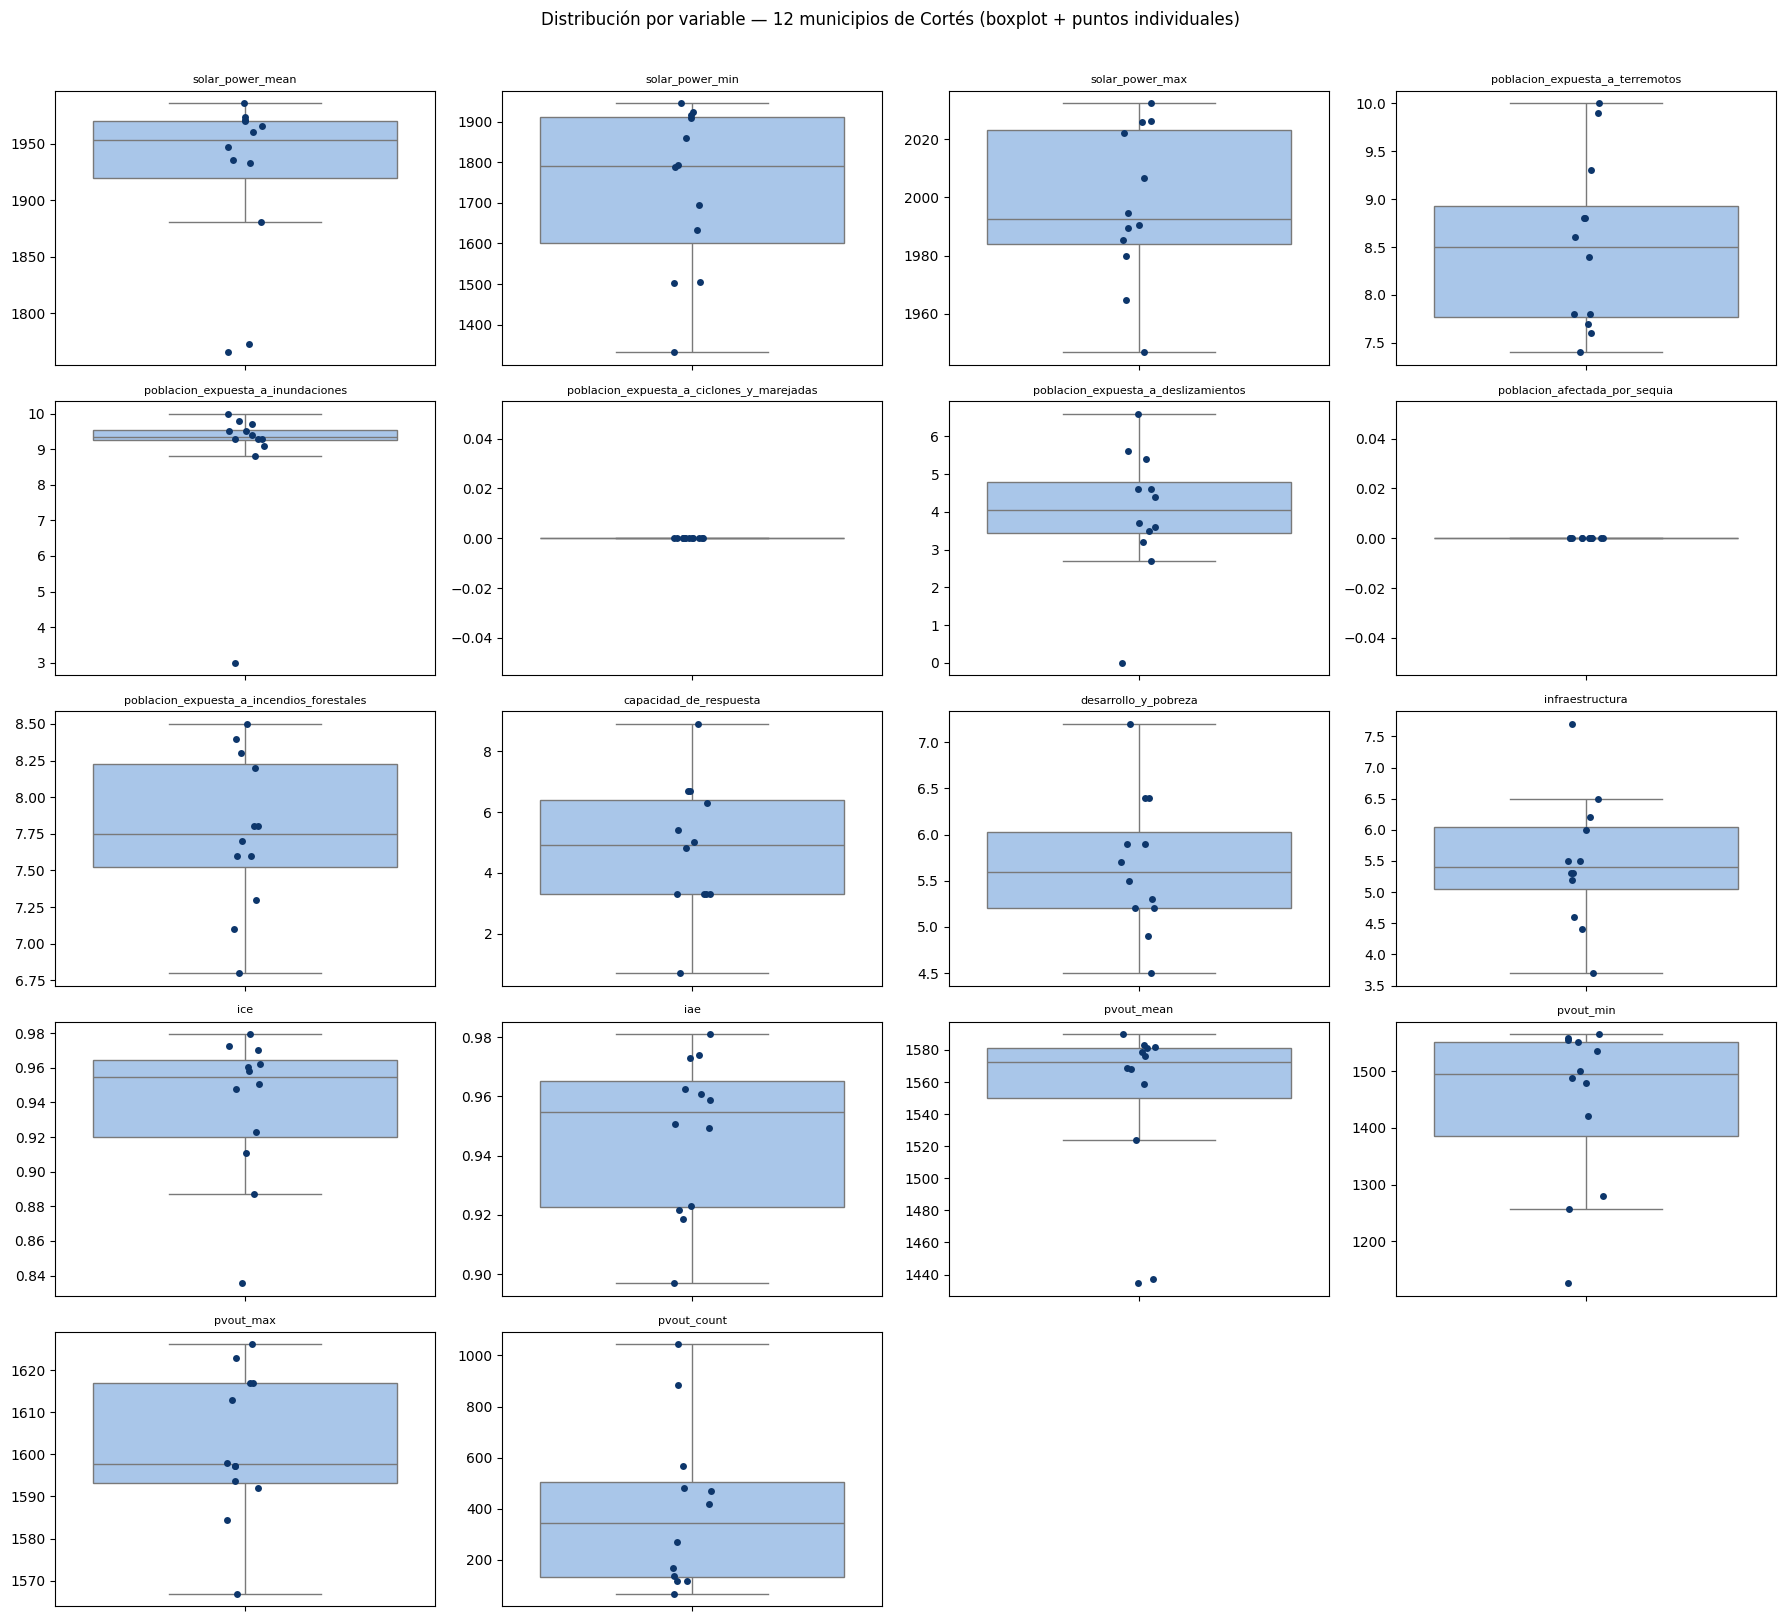

In [3]:
fig, axes = plt.subplots(nrows=int(np.ceil(len(numeric_cols) / 4)), ncols=4,
                          figsize=(18, 3.2 * np.ceil(len(numeric_cols) / 4)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#9ec5f4", fliersize=0)
    sns.stripplot(y=df[col], ax=axes[i], color="#0d366b", size=5, jitter=0.05)
    axes[i].set_title(col, fontsize=8)
    axes[i].set_ylabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribución por variable — 12 municipios de Cortés (boxplot + puntos individuales)", y=1.01)
plt.tight_layout()
plt.show()


**Hallazgo clave:** `poblacion_expuesta_a_ciclones_y_marejadas` y
`poblacion_afectada_por_sequia` tienen **varianza cero dentro de Cortés** (los 12 municipios
reportan 0.0): a nivel nacional discriminan, pero para este territorio no aportan nada al
índice — se excluyen de la selección de variables más adelante, y se documenta el hallazgo en
el informe en vez de forzarlas en el índice.

## Bloque 2 — Matriz de correlación (detectar redundancia)

Si dos variables correlacionan muy fuerte (|r| ≥ 0.8) están midiendo casi lo mismo dentro de
esta muestra. Con n=12 estas correlaciones son poco estables (un solo municipio atípico puede
mover mucho el coeficiente), así que se usan como **evidencia de apoyo**, no como criterio
único, y se contrastan con el significado de cada variable antes de descartar algo.

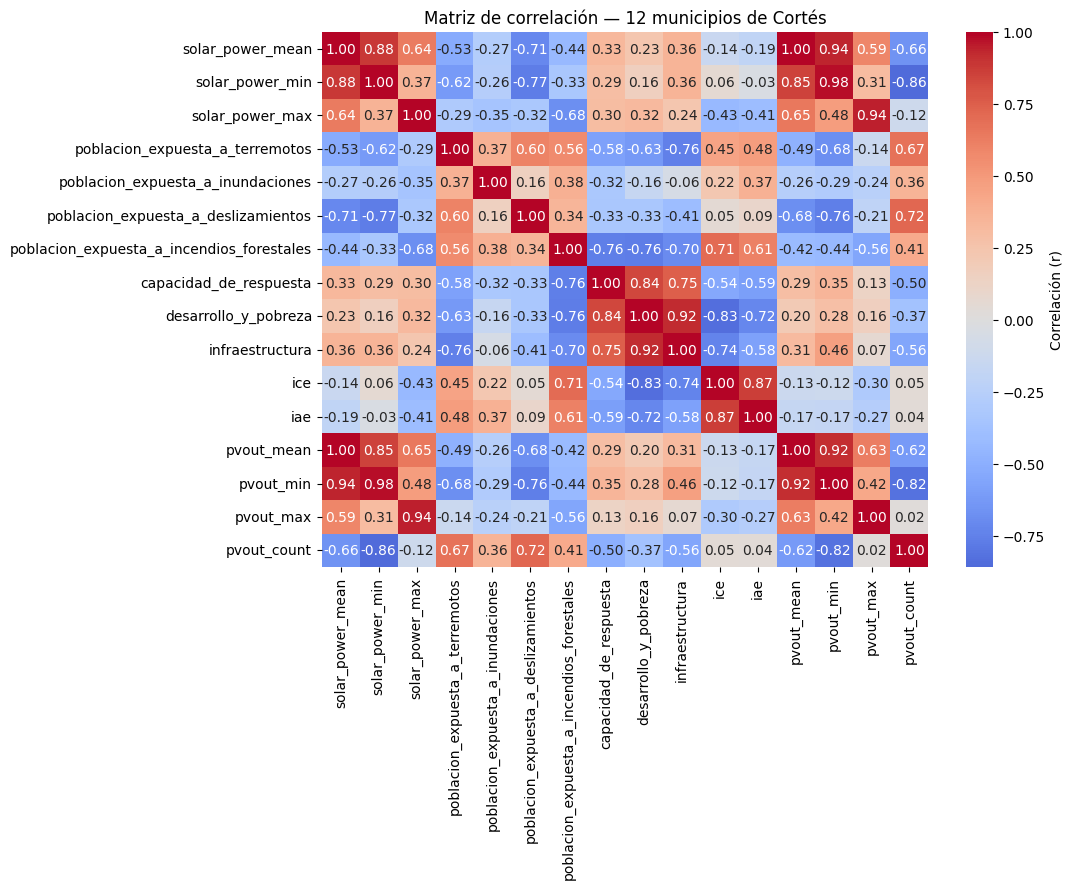

,var_1,var_2,correlacion
1,solar_power_mean,pvout_mean,0.996
4,solar_power_min,pvout_min,0.975
6,solar_power_max,pvout_max,0.943
2,solar_power_mean,pvout_min,0.937
8,desarrollo_y_pobreza,infraestructura,0.921
11,pvout_mean,pvout_min,0.918
0,solar_power_mean,solar_power_min,0.880
10,ice,iae,0.867
5,solar_power_min,pvout_count,-0.859
3,solar_power_min,pvout_mean,0.855


In [4]:
def plot_correlation(data: pd.DataFrame, cols: list, threshold: float = 0.8):
    """Mapa de calor de correlación y lista de pares por encima del umbral."""
    corr = data[cols].corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                cbar_kws={"label": "Correlación (r)"})
    plt.title("Matriz de correlación — 12 municipios de Cortés")
    plt.tight_layout()
    plt.show()

    pares_altos = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            if pd.notna(r) and abs(r) >= threshold:
                pares_altos.append((cols[i], cols[j], round(r, 3)))
    return pd.DataFrame(pares_altos, columns=["var_1", "var_2", "correlacion"])


cols_para_correlacion = [c for c in numeric_cols if df[c].std() > 0]  # excluye varianza cero
high_corr = plot_correlation(df, cols_para_correlacion)
high_corr.sort_values("correlacion", key=abs, ascending=False)


## Bloque 3 — Selección final de variables

Decisiones, con su justificación (esto es lo que se defiende oralmente):

| Variable | Decisión | Justificación |
|---|---|---|
| `pvout_mean` | **Se usa como variable solar del índice** | Correlaciona ~0.99 con `solar_power_mean` (GHI) dentro de Cortés — ver `gda.ipynb`. Se prefiere PVOUT porque representa generación eléctrica real, más relevante para viabilidad de proyectos. |
| `solar_power_mean` (GHI) | Se excluye del índice, se mantiene solo como referencia descriptiva | Redundante con PVOUT (multicolinealidad); incluir ambas duplicaría el peso del componente solar. |
| `poblacion_expuesta_a_ciclones_y_marejadas` | Se excluye | Varianza cero en Cortés (los 12 municipios reportan 0.0): no discrimina. |
| `poblacion_afectada_por_sequia` | Se excluye | Varianza cero en Cortés: no discrimina. |
| `poblacion_expuesta_a_terremotos`, `..._inundaciones`, `..._deslizamientos`, `..._incendios_forestales` | Se incluyen (riesgo climático) | Sí varían entre municipios de Cortés y son ejes de riesgo distintos (no redundantes entre sí, ver matriz de correlación). |
| `capacidad_de_respuesta`, `iae` | Se incluyen (capacidad adaptativa) | Miden la capacidad de mitigar/adaptarse al riesgo, un concepto distinto de la exposición cruda a amenazas. |
| `ice` | Se excluye | Correlaciona fuerte con `iae` (ver matriz) — mismo concepto de adaptación medido dos veces. |
| `infraestructura` | Se incluye | Es explícitamente uno de los tres criterios de la pregunta del informe ("infraestructura aceptable"). |
| `desarrollo_y_pobreza` | Se excluye del índice de este parcial | Es el tema central del bloque "Pobreza y Seguridad Alimentaria" del **Parcial 2** (semana 9); incluirlo aquí duplicaría ese análisis y desviaría el índice de su foco solar-climático. Se deja disponible en el dataset para retomarlo explícitamente en el Parcial 2. |

In [5]:
selected_vars = [
    "pvout_mean",
    "poblacion_expuesta_a_terremotos",
    "poblacion_expuesta_a_inundaciones",
    "poblacion_expuesta_a_deslizamientos",
    "poblacion_expuesta_a_incendios_forestales",
    "capacidad_de_respuesta",
    "iae",
    "infraestructura",
]

id_vars = ["departamento", "municipio", "codigo_departamental", "codigo_municipal"]
df_model = df[id_vars + selected_vars + ["solar_power_mean"]].copy()  # GHI se conserva solo como referencia
df_model.head(12)


,departamento,municipio,codigo_departamental,codigo_municipal,pvout_mean,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_deslizamientos,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,iae,infraestructura,solar_power_mean
0,Cortes,Puerto Cortes,HN05,HN0506,1568.190027,9.3,9.4,3.6,7.7,3.3,0.9731,4.4,1935.149874
1,Cortes,Omoa,HN05,HN0503,1434.468620,8.4,9.3,5.6,7.8,6.7,0.9216,6.2,1773.281026
2,Cortes,Choloma,HN05,HN0502,1523.873900,9.9,9.8,5.4,8.3,4.8,0.9741,4.6,1880.486177
3,Cortes,San Pedro Sula,HN05,HN0501,1437.203739,10.0,10.0,6.6,8.4,0.7,0.9810,3.7,1765.359245
4,Cortes,La Lima,HN05,HN0512,1582.066866,8.8,9.7,4.6,7.8,3.3,0.9626,5.3,1969.962451
5,Cortes,San Manuel,HN05,HN0509,1576.124632,8.6,9.3,2.7,8.5,3.3,0.9607,5.5,1965.433403
6,Cortes,San Antonio De Cortes,HN05,HN0507,1568.550651,7.7,8.8,3.7,6.8,6.7,0.9187,7.7,1946.788571
7,Cortes,Santa Cruz De Yojoa,HN05,HN0510,1578.516930,8.8,9.5,4.6,7.6,5.0,0.8969,5.3,1960.350046
8,Cortes,Villanueva,HN05,HN0511,1559.014881,7.4,9.3,4.4,8.2,3.3,0.9588,5.5,1932.817660
9,Cortes,Pimienta,HN05,HN0504,1581.178079,7.6,9.5,0.0,7.6,5.4,0.9506,6.0,1973.704833


## Bloque 4 — Datos faltantes

En el dataset nacional, `poblacion_expuesta_a_inundaciones`, `ice` e `iae` tienen valores
faltantes (municipios muy aislados o insulares donde no se reportó el indicador). **Dentro de
los 12 municipios de Cortés no hay ningún valor faltante** en las variables seleccionadas, así
que no se requiere imputar nada para este territorio.

Se deja documentada la función de imputación por mediana departamental (`impute_by_group`)
por si el análisis se extiende a otros departamentos en el Parcial 2 — pero no se invoca aquí
porque no hace falta, y usarla sin necesidad sería un supuesto metodológico no declarado.

In [6]:
def impute_by_group(data: pd.DataFrame, cols: list, group_col: str = "departamento") -> pd.DataFrame:
    """Imputa con la mediana del grupo (p.ej. departamento). Si el grupo completo está vacío,
    usa la mediana global como respaldo. No se usa en este notebook (Cortés no tiene datos
    faltantes en las variables seleccionadas) — se deja disponible para extender el análisis."""
    data = data.copy()
    for col in cols:
        data[col] = data.groupby(group_col)[col].transform(lambda x: x.fillna(x.median()))
        data[col] = data[col].fillna(data[col].median())
    return data


faltantes = df_model[selected_vars].isnull().sum()
print("Valores faltantes por variable seleccionada (Cortés):")
print(faltantes)
assert faltantes.sum() == 0, "Hay datos faltantes en Cortés: se requeriría imputar (no esperado)."
print("\nOK: no se requiere imputación para este territorio.")


Valores faltantes por variable seleccionada (Cortés):
pvout_mean                                   0
poblacion_expuesta_a_terremotos              0
poblacion_expuesta_a_inundaciones            0
poblacion_expuesta_a_deslizamientos          0
poblacion_expuesta_a_incendios_forestales    0
capacidad_de_respuesta                       0
iae                                          0
infraestructura                              0
dtype: int64

OK: no se requiere imputación para este territorio.


## Bloque 5 — Construcción de sub-índices (normalización min-max con dirección)

En vez de normalizar 8 variables sueltas y ponderarlas todas juntas (lo que hacía que el peso
de "riesgo" dependiera de cuántas variables de riesgo se hubieran incluido), se agrupan
primero en **cuatro sub-índices interpretables**, cada uno normalizado a [0,1] donde
**1 siempre es "mejor"**:

1. **Potencial solar** — `pvout_mean` (mayor es mejor).
2. **Seguridad climática** — promedio de las 4 variables de exposición a amenazas, invertidas
   (mayor exposición → menor seguridad). Un valor de 1 significa "el municipio con menor
   exposición combinada a amenazas de todo Cortés"; no significa "riesgo cero".
3. **Capacidad adaptativa** — promedio de `capacidad_de_respuesta` e `iae` (mayor es mejor).
4. **Infraestructura** — `infraestructura` (mayor es mejor).

Esto evita que el número de variables de riesgo infle artificialmente el peso del riesgo
frente a infraestructura o capacidad adaptativa.

In [7]:
def normalize_min_max(series: pd.Series, invert: bool = False) -> pd.Series:
    """Normaliza a [0,1]. Si invert=True, valores altos originales -> puntaje bajo
    (usar para indicadores donde "mayor es peor", como exposición a riesgo)."""
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series(0.5, index=series.index)  # sin variacion: no discrimina
    norm = (series - min_val) / (max_val - min_val)
    return 1 - norm if invert else norm


hazard_vars = [
    "poblacion_expuesta_a_terremotos",
    "poblacion_expuesta_a_inundaciones",
    "poblacion_expuesta_a_deslizamientos",
    "poblacion_expuesta_a_incendios_forestales",
]
adapt_vars = ["capacidad_de_respuesta", "iae"]

sub = df_model[id_vars].copy()

sub["potencial_solar"] = normalize_min_max(df_model["pvout_mean"])

for v in hazard_vars:
    sub[f"_{v}_seguro"] = normalize_min_max(df_model[v], invert=True)
sub["seguridad_climatica"] = sub[[f"_{v}_seguro" for v in hazard_vars]].mean(axis=1)

for v in adapt_vars:
    sub[f"_{v}_norm"] = normalize_min_max(df_model[v])
sub["capacidad_adaptativa"] = sub[[f"_{v}_norm" for v in adapt_vars]].mean(axis=1)

sub["infraestructura"] = normalize_min_max(df_model["infraestructura"])

sub = sub.drop(columns=[c for c in sub.columns if c.startswith("_")])
sub.round(3)


,departamento,municipio,codigo_departamental,codigo_municipal,potencial_solar,seguridad_climatica,capacidad_adaptativa,infraestructura
0,Cortes,Puerto Cortes,HN05,HN0506,0.861,0.320,0.612,0.175
1,Cortes,Omoa,HN05,HN0503,0.000,0.320,0.513,0.625
2,Cortes,Choloma,HN05,HN0502,0.576,0.092,0.709,0.225
3,Cortes,San Pedro Sula,HN05,HN0501,0.018,0.015,0.500,0.000
4,Cortes,La Lima,HN05,HN0512,0.950,0.305,0.549,0.400
5,Cortes,San Manuel,HN05,HN0509,0.912,0.307,0.538,0.450
6,Cortes,San Antonio De Cortes,HN05,HN0507,0.863,0.624,0.495,1.000
7,Cortes,Santa Cruz De Yojoa,HN05,HN0510,0.927,0.341,0.262,0.400
8,Cortes,Villanueva,HN05,HN0511,0.802,0.402,0.527,0.450
9,Cortes,Pimienta,HN05,HN0504,0.944,0.631,0.606,0.575


## Bloque 6 — Ponderación y cálculo del Índice de Potencial Solar-Climático (IPS)

Suma ponderada lineal de los cuatro sub-índices. Pesos y justificación:

- **Potencial solar (0.40):** factor técnico dominante — sin buen recurso solar no hay
  proyecto viable, independientemente de lo demás.
- **Seguridad climática (0.25):** sostenibilidad de la inversión frente a amenazas —
  un proyecto en zona de alto riesgo compromete su retorno y su vida útil.
- **Infraestructura (0.20):** condiciona la facilidad de implementación y conexión a la red
  eléctrica existente — es uno de los tres criterios explícitos que pide el informe.
- **Capacidad adaptativa (0.15):** factor mitigador/complementario del riesgo climático.

Los pesos son un juicio de diseño (típico de un índice compuesto) y **deben poder
defenderse**, no solo calcularse — por eso cada uno tiene una razón explícita arriba, y el
Bloque 7 comprueba qué tan sensible es el resultado a estos números.

In [8]:
weights = {
    "potencial_solar": 0.40,
    "seguridad_climatica": 0.25,
    "infraestructura": 0.20,
    "capacidad_adaptativa": 0.15,
}

assert abs(sum(weights.values()) - 1.0) < 1e-9, "Los pesos deben sumar 1.0"


def compute_composite_index(data: pd.DataFrame, weights: dict, index_name: str = "IPS") -> pd.DataFrame:
    """Índice compuesto: suma ponderada lineal de columnas ya normalizadas a [0,1]."""
    data = data.copy()
    data[index_name] = sum(data[col] * w for col, w in weights.items())
    return data


df_index = compute_composite_index(sub, weights)
df_index = df_index.sort_values("IPS", ascending=False).reset_index(drop=True)
df_index[["municipio", "potencial_solar", "seguridad_climatica", "infraestructura", "capacidad_adaptativa", "IPS"]].round(3)


,municipio,potencial_solar,seguridad_climatica,infraestructura,capacidad_adaptativa,IPS
0,Potrerillos,1.000,0.578,0.700,0.812,0.806
1,San Antonio De Cortes,0.863,0.624,1.000,0.495,0.776
2,Pimienta,0.944,0.631,0.575,0.606,0.741
3,San Francisco De Yojoa,0.955,0.755,0.375,0.497,0.720
4,La Lima,0.950,0.305,0.400,0.549,0.619
5,San Manuel,0.912,0.307,0.450,0.538,0.612
6,Villanueva,0.802,0.402,0.450,0.527,0.590
7,Santa Cruz De Yojoa,0.927,0.341,0.400,0.262,0.576
8,Puerto Cortes,0.861,0.320,0.175,0.612,0.551
9,Choloma,0.576,0.092,0.225,0.709,0.404


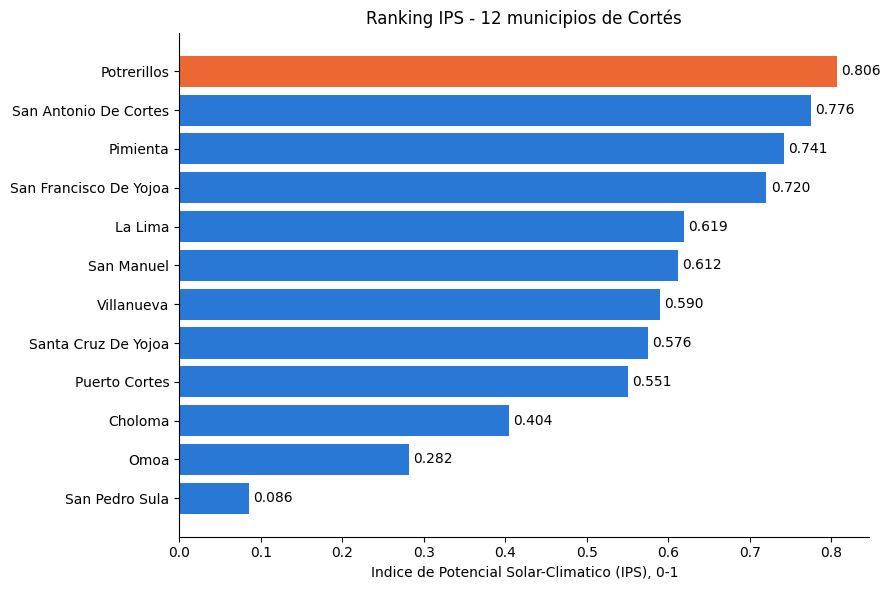

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
orden = df_index.sort_values("IPS")
colores = ["#eb6834" if v == df_index["IPS"].max() else "#2a78d6" for v in orden["IPS"]]
bars = ax.barh(orden["municipio"], orden["IPS"], color=colores)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Indice de Potencial Solar-Climatico (IPS), 0-1")
ax.set_title("Ranking IPS - 12 municipios de Cortés")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Bloque 7 — Análisis de sensibilidad

Con solo 12 municipios, "estar en el top 5" (como en la versión anterior, pensada para 298
municipios) ya no es un buen umbral — equivale a casi la mitad de la muestra. Se usa en
cambio el **top 4** (el tamaño de un tercil, ver Bloque 8), y se perturba cada peso ±10%,
20 veces, para ver qué tan estable es ese grupo frente a la elección de pesos.

In [10]:
def sensitivity_test(data: pd.DataFrame, weights: dict, top_n: int = 4,
                      pct_change: float = 0.10, n_runs: int = 200, seed: int = 42) -> pd.Series:
    """Perturba cada peso +/- pct_change, renormaliza a suma 1, recalcula el indice,
    y cuenta cuantas veces cada municipio queda en el top_n."""
    rng = np.random.default_rng(seed)
    top_counter = {}

    for _ in range(n_runs):
        perturbed = {col: max(w * (1 + rng.uniform(-pct_change, pct_change)), 0)
                     for col, w in weights.items()}
        total = sum(perturbed.values())
        perturbed = {col: w / total for col, w in perturbed.items()}

        temp = compute_composite_index(data, perturbed, index_name="_temp_index")
        top = temp.nlargest(top_n, "_temp_index")["municipio"]
        for m in top:
            top_counter[m] = top_counter.get(m, 0) + 1

    result = pd.Series(top_counter, name="pct_runs_in_top4").sort_values(ascending=False)
    return (result / n_runs * 100).round(1)


sensitivity_result = sensitivity_test(df_index, weights)
sensitivity_result


Potrerillos               100.0
San Antonio De Cortes     100.0
Pimienta                  100.0
San Francisco De Yojoa    100.0
Name: pct_runs_in_top4, dtype: float64

## Bloque 8 — Preselección final por terciles

Se clasifica cada municipio en **terciles** (Bajo / Medio / Alto, ~4 municipios cada uno)
sobre las tres dimensiones que pide el informe, y se aplica el filtro literal de la pregunta:

- **Alta irradiación/generación:** tercil **Alto** de `potencial_solar` (PVOUT).
- **Riesgo climático bajo o moderado:** tercil de `seguridad_climatica` **distinto de Bajo**
  (recordar: `seguridad_climatica` alta = riesgo bajo; se excluye solo el tercil más
  inseguro).
- **Infraestructura aceptable:** tercil de `infraestructura` **distinto de Bajo** (no se
  exige "excelente", solo que no esté en el tercio más débil).

In [11]:
def clasificar_terciles(serie: pd.Series, etiquetas=("Bajo", "Medio", "Alto")) -> pd.Series:
    rangos = serie.rank(method="first")
    return pd.qcut(rangos, 3, labels=etiquetas)


df_index["tercil_potencial_solar"] = clasificar_terciles(df_index["potencial_solar"])
df_index["tercil_seguridad_climatica"] = clasificar_terciles(df_index["seguridad_climatica"])
df_index["tercil_infraestructura"] = clasificar_terciles(df_index["infraestructura"])

tabla_terciles = df_index[[
    "municipio", "tercil_potencial_solar", "tercil_seguridad_climatica", "tercil_infraestructura", "IPS"
]].sort_values("IPS", ascending=False)
tabla_terciles


,municipio,tercil_potencial_solar,tercil_seguridad_climatica,tercil_infraestructura,IPS
0,Potrerillos,Alto,Alto,Alto,0.806407
1,San Antonio De Cortes,Medio,Alto,Alto,0.775550
2,Pimienta,Alto,Alto,Alto,0.741404
3,San Francisco De Yojoa,Alto,Alto,Bajo,0.720457
4,La Lima,Alto,Bajo,Medio,0.618641
5,San Manuel,Medio,Bajo,Medio,0.612282
6,Villanueva,Bajo,Medio,Medio,0.590306
7,Santa Cruz De Yojoa,Medio,Medio,Medio,0.575597
8,Puerto Cortes,Medio,Medio,Bajo,0.551077
9,Choloma,Bajo,Bajo,Bajo,0.404474


In [12]:
cumple_solar = df_index["tercil_potencial_solar"] == "Alto"
cumple_riesgo = df_index["tercil_seguridad_climatica"] != "Bajo"
cumple_infra = df_index["tercil_infraestructura"] != "Bajo"

preseleccion = df_index[cumple_solar & cumple_riesgo & cumple_infra].sort_values("IPS", ascending=False)
casi_califican = df_index[
    (cumple_solar.astype(int) + cumple_riesgo.astype(int) + cumple_infra.astype(int) == 2)
    & ~(cumple_solar & cumple_riesgo & cumple_infra)
].sort_values("IPS", ascending=False)

print(f"Preseleccion final ({len(preseleccion)} municipios cumplen los 3 criterios):")
display(preseleccion[["municipio", "tercil_potencial_solar", "tercil_seguridad_climatica", "tercil_infraestructura", "IPS"]])

print(f"\nCasi califican (cumplen 2 de 3 criterios, {len(casi_califican)} municipios):")
display(casi_califican[["municipio", "tercil_potencial_solar", "tercil_seguridad_climatica", "tercil_infraestructura", "IPS"]])


Preseleccion final (2 municipios cumplen los 3 criterios):


,municipio,tercil_potencial_solar,tercil_seguridad_climatica,tercil_infraestructura,IPS
0,Potrerillos,Alto,Alto,Alto,0.806407
2,Pimienta,Alto,Alto,Alto,0.741404



Casi califican (cumplen 2 de 3 criterios, 6 municipios):


,municipio,tercil_potencial_solar,tercil_seguridad_climatica,tercil_infraestructura,IPS
1,San Antonio De Cortes,Medio,Alto,Alto,0.775550
3,San Francisco De Yojoa,Alto,Alto,Bajo,0.720457
4,La Lima,Alto,Bajo,Medio,0.618641
6,Villanueva,Bajo,Medio,Medio,0.590306
7,Santa Cruz De Yojoa,Medio,Medio,Medio,0.575597
10,Omoa,Bajo,Medio,Alto,0.281822


## Bloque 9 — Visualización de la preselección

Dispersograma de potencial solar (x) vs. seguridad climática (y) — los dos ejes "continuos"
de la pregunta —, con el tercil de infraestructura codificado como color de estado
(bueno/advertencia/serio, no como categoría arbitraria) y un contorno destacado para los
municipios preseleccionados.

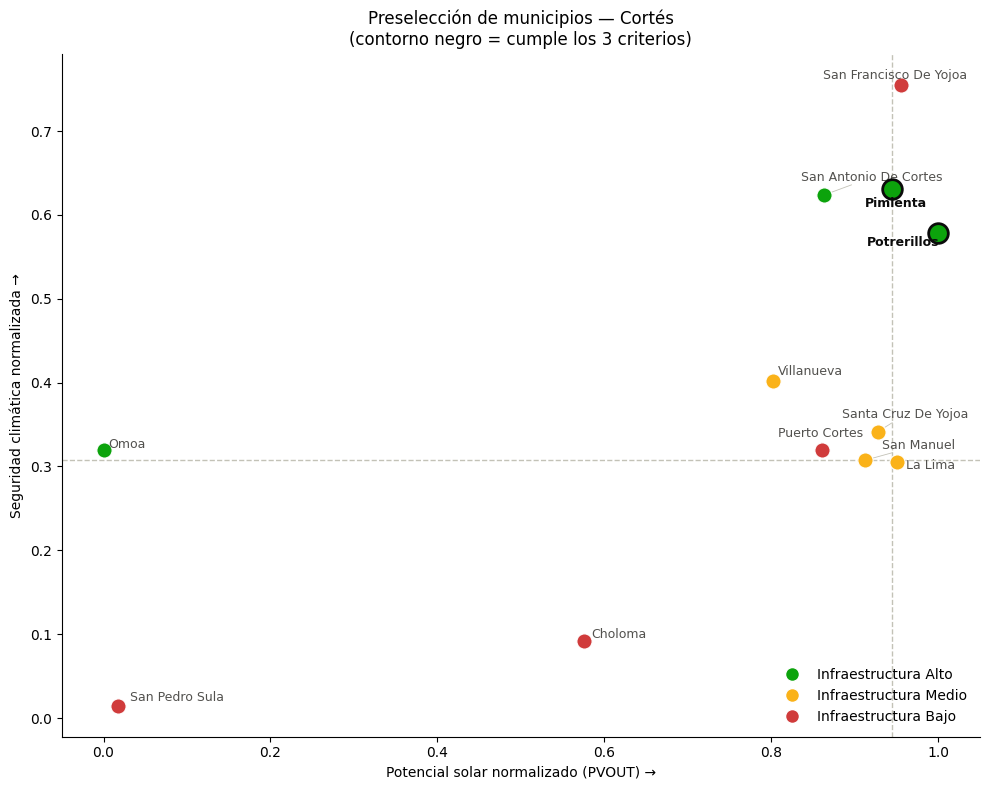

In [13]:
COLOR_INFRA = {"Alto": "#0ca30c", "Medio": "#fab219", "Bajo": "#d03b3b"}

fig, ax = plt.subplots(figsize=(10, 8))

etiquetas = []
for _, row in df_index.iterrows():
    es_preseleccionado = row["municipio"] in preseleccion["municipio"].values
    ax.scatter(
        row["potencial_solar"], row["seguridad_climatica"],
        s=200 if es_preseleccionado else 120,
        color=COLOR_INFRA[str(row["tercil_infraestructura"])],
        edgecolor="#0b0b0b" if es_preseleccionado else "white",
        linewidth=2 if es_preseleccionado else 0.8,
        zorder=3,
    )
    etiquetas.append(ax.text(
        row["potencial_solar"], row["seguridad_climatica"], row["municipio"], fontsize=9,
        fontweight="bold" if es_preseleccionado else "normal",
        color="#0b0b0b" if es_preseleccionado else "#52514e",
    ))

try:
    from adjustText import adjust_text
    adjust_text(etiquetas, ax=ax, arrowprops=dict(arrowstyle="-", color="#c3c2b7", lw=0.6))
except ImportError:
    print("Sugerencia: 'pip install adjustText' evita que las etiquetas de municipios se encimen.")

ax.axvline(df_index.loc[df_index["tercil_potencial_solar"] == "Alto", "potencial_solar"].min(),
           color="#c3c2b7", linestyle="--", linewidth=1)
ax.axhline(df_index.loc[df_index["tercil_seguridad_climatica"] == "Bajo", "seguridad_climatica"].max(),
           color="#c3c2b7", linestyle="--", linewidth=1)

leyenda = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=f"Infraestructura {k}")
           for k, c in COLOR_INFRA.items()]
ax.legend(handles=leyenda, loc="lower right", frameon=False)

ax.set_xlabel("Potencial solar normalizado (PVOUT) →")
ax.set_ylabel("Seguridad climática normalizada →")
ax.set_title("Preselección de municipios — Cortés\n(contorno negro = cumple los 3 criterios)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Bloque 10 — Exportar resultados

In [14]:
columnas_exportar = id_vars + [
    "potencial_solar", "seguridad_climatica", "infraestructura", "capacidad_adaptativa", "IPS",
    "tercil_potencial_solar", "tercil_seguridad_climatica", "tercil_infraestructura",
]
resultado_final = df_index[columnas_exportar].copy()
resultado_final["preseleccionado"] = resultado_final["municipio"].isin(preseleccion["municipio"])

OUT_PATH = ROOT / "data/index/processed/preseleccion_solar_cortes.csv"
resultado_final.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"Exportado: {OUT_PATH.name}")
resultado_final.sort_values("IPS", ascending=False)


Exportado: preseleccion_solar_cortes.csv


,departamento,municipio,codigo_departamental,codigo_municipal,potencial_solar,seguridad_climatica,infraestructura,capacidad_adaptativa,IPS,tercil_potencial_solar,tercil_seguridad_climatica,tercil_infraestructura,preseleccionado
0,Cortes,Potrerillos,HN05,HN0505,1.000000,0.578352,0.700,0.812128,0.806407,Alto,Alto,Alto,True
1,Cortes,San Antonio De Cortes,HN05,HN0507,0.863164,0.623859,1.000,0.495461,0.775550,Medio,Alto,Alto,False
2,Cortes,Pimienta,HN05,HN0504,0.944454,0.630979,0.575,0.605848,0.741404,Alto,Alto,Alto,True
3,Cortes,San Francisco De Yojoa,HN05,HN0508,0.955035,0.755433,0.375,0.497230,0.720457,Alto,Alto,Bajo,False
4,Cortes,La Lima,HN05,HN0512,0.950176,0.304798,0.400,0.549143,0.618641,Alto,Bajo,Medio,False
5,Cortes,San Manuel,HN05,HN0509,0.911922,0.307343,0.450,0.537847,0.612282,Medio,Bajo,Medio,False
6,Cortes,Villanueva,HN05,HN0511,0.801777,0.402451,0.450,0.526551,0.590306,Bajo,Medio,Medio,False
7,Cortes,Santa Cruz De Yojoa,HN05,HN0510,0.927323,0.341352,0.400,0.262195,0.575597,Medio,Medio,Medio,False
8,Cortes,Puerto Cortes,HN05,HN0506,0.860843,0.320020,0.175,0.611569,0.551077,Medio,Medio,Bajo,False
9,Cortes,Choloma,HN05,HN0502,0.575554,0.091625,0.225,0.708977,0.404474,Bajo,Bajo,Bajo,False


## Conclusión — respuesta a la pregunta del informe

*De los 12 municipios de Cortés, ¿cuáles combinan alta irradiación, bajo/moderado riesgo
climático e infraestructura aceptable?*

Los resultados de este notebook (ver tabla de preselección del Bloque 8 y el gráfico del
Bloque 9) son la base para redactar esta respuesta en la sección "Conclusiones y preguntas
abiertas" del Informe de Diagnóstico. Como referencia con los datos usados en esta corrida:
los municipios que cumplen simultáneamente los tres criterios quedan en `preseleccion`
(Bloque 8), y los que cumplen exactamente 2 de 3 quedan en `casi_califican` — la tabla de
`casi_califican` indica, para cada uno, cuál de los tres terciles es el que no alcanzan
(puede ser potencial solar, seguridad climática o infraestructura, según el caso). Vale la
pena mencionarlos en el informe junto con el criterio específico que les falta: son
candidatos naturales a revisar si en el Parcial 2 cambian las condiciones de ese criterio
puntual (p. ej. una mejora de red eléctrica o de acceso vial).

Esta lista corta es el puente hacia el **Parcial 2**: los municipios preseleccionados son el
punto de partida natural para el bloque de energía (¿dónde ubicar un proyecto solar piloto?),
movilidad (¿qué tan accesibles son hoy?) y — de forma explícitamente separada, como se
documentó en el Bloque 3 — el bloque de pobreza/seguridad alimentaria, que retoma
`desarrollo_y_pobreza`.